# Centroid grid v2 — statistical analysis

Loads saved `prediction_metrics.csv` from each (setting, model) run and computes:

- **Median ± SE** of centroid distance and RMSE across double-perturbation conditions
- **One-tailed Wilcoxon signed-rank p-value** vs gCRL-VAE (same setting) for CMVAE-full and CMVAE-comp
- **One-tailed Wilcoxon signed-rank p-value** vs anchor setting (`01_mmd20`) for all models

All tests are one-tailed (H1: other method/setting is *better* than reference, i.e. lower centroid distance).
Pairs are matched on (cell_type, intervention).

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

BASE_DIR = "../../results/real/Norman2019/centroid_grid_v2"
METRIC   = "centroid_distance"
METHODS  = ["actual", "worst_case", "perfect_baseline"]

SETTINGS = [
    "01_mmd20",
    "02_mmd30",
    "03_mmd40",
    "04_mmd20_kld01",
    "05_mmd30_kld01",
    "06_mmd20_lr3e3",
    "07_mmd20_epochs150",
    "08_mmd20_mcc5",
    "09_mmd20_sparse1e4",
    "10_mmd30_kld01_mcc5",
]

SUBMODELS = ["cmvae_full", "cmvae_comp", "gcrl_vae"]
ANCHOR_SETTING = "01_mmd20"

## 1. Load all metrics

In [14]:
raw = {}   # (setting, model, method) -> DataFrame with columns [cell_type, intervention, metric_value]

for name in SETTINGS:
    for sub in SUBMODELS:
        path = f"{BASE_DIR}/{name}/{sub}/prediction_metrics.csv"
        df = pd.read_csv(path)
        df = df[df["metric_name"] == METRIC]
        for method in METHODS:
            raw[(name, sub, method)] = df[df["method"] == method][
                ["cell_type", "intervention", "metric_value"]
            ].copy()

print(f"Loaded {len(raw)} (setting, model, method) slices")
print(f"Conditions per slice: {len(next(iter(raw.values())))}")

Loaded 90 (setting, model, method) slices
Conditions per slice: 12


## 2. Summary table: median ± SE per (setting, model)

In [15]:
def se(x):
    return x.std(ddof=1) / np.sqrt(len(x))

rows = []
for name in SETTINGS:
    for sub in SUBMODELS:
        for method in METHODS:
            vals = raw[(name, sub, method)]["metric_value"]
            rows.append({
                "setting": name,
                "model":   sub,
                "method":  method,
                "median":  vals.median(),
                "se":      se(vals),
                "n":       len(vals),
            })

summary = pd.DataFrame(rows)

# Summary table: actual predictions only, rows = setting, cols = model
actual_only = summary[summary["method"] == "actual"]
pivot_med = actual_only.pivot_table(
    index="setting", columns="model", values="median", aggfunc="first"
).reindex(SETTINGS).round(4)
pivot_se = actual_only.pivot_table(
    index="setting", columns="model", values="se", aggfunc="first"
).reindex(SETTINGS).round(4)

print(f"Median {METRIC} (actual) across double-perturbation conditions:")
pivot_med

Median centroid_distance (actual) across double-perturbation conditions:


model,cmvae_comp,cmvae_full,gcrl_vae
setting,,,
01_mmd20,3.4621,3.1212,3.2697
02_mmd30,3.6790,3.6328,3.2511
03_mmd40,3.2351,3.4737,3.2536
04_mmd20_kld01,3.3625,4.1535,3.1538
05_mmd30_kld01,3.5043,4.1378,3.1961
06_mmd20_lr3e3,4.3997,5.0379,3.4858
07_mmd20_epochs150,3.8919,3.2455,3.4570
08_mmd20_mcc5,3.4621,3.1212,3.3082
09_mmd20_sparse1e4,3.5286,3.3831,3.2839


## 3. Wilcoxon tests: gCRL-VAE vs all four references (per setting)

For each setting, gCRL-VAE (actual predictions) is compared against:
- CMVAE-full actual predictions
- CMVAE-comp actual predictions
- worst_case predictions (controls used as predictions)
- perfect_baseline predictions

Two-tailed Wilcoxon signed-rank test. Pairs matched on (cell_type, intervention).

In [16]:
def paired_wilcoxon(a_df, b_df, key_cols=["cell_type", "intervention"]):
    """Two-tailed Wilcoxon signed-rank test on matched pairs."""
    merged = a_df.merge(b_df, on=key_cols, suffixes=("_a", "_b"))
    diff = merged["metric_value_a"] - merged["metric_value_b"]
    diff = diff[diff != 0]
    if len(diff) < 5:
        return np.nan
    _, p_two = wilcoxon(diff)
    return p_two

def sig_stars(p):
    if np.isnan(p): return ""
    return "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))

# References: (label, model_key, method_key)
REFERENCES = [
    ("vs_cmvae_full", "cmvae_full", "actual"),
    ("vs_cmvae_comp", "cmvae_comp", "actual"),
    ("vs_worst_case", "gcrl_vae",   "worst_case"),
    ("vs_perfect",    "gcrl_vae",   "perfect_baseline"),
]

gcrl_rows = []
for name in SETTINGS:
    gcrl_df = raw[(name, "gcrl_vae", "actual")]
    for ref_label, ref_model, ref_method in REFERENCES:
        ref_df = raw[(name, ref_model, ref_method)]
        p = paired_wilcoxon(gcrl_df, ref_df)
        med_gcrl = gcrl_df["metric_value"].median()
        med_ref  = ref_df["metric_value"].median()
        gcrl_rows.append({
            "setting":     name,
            "reference":   ref_label,
            "gcrl_median": med_gcrl,
            "gcrl_se":     se(gcrl_df["metric_value"]),
            "ref_median":  med_ref,
            "ref_se":      se(ref_df["metric_value"]),
            "delta":       med_gcrl - med_ref,
            "p_value":     p,
            "sig":         sig_stars(p),
        })

gcrl_vs = pd.DataFrame(gcrl_rows)
print("Two-tailed Wilcoxon signed-rank test: gCRL-VAE vs reference")
print("Negative delta = gCRL-VAE has lower centroid distance than reference\n")

for ref_label, _, _ in REFERENCES:
    sub = gcrl_vs[gcrl_vs["reference"] == ref_label].sort_values("setting")
    print(f"--- gCRL-VAE {ref_label} ---")
    print(sub[["setting", "gcrl_median", "gcrl_se", "ref_median", "ref_se", "delta", "p_value", "sig"]].to_string(index=False))
    print()

Two-tailed Wilcoxon signed-rank test: gCRL-VAE vs reference
Negative delta = gCRL-VAE has lower centroid distance than reference

--- gCRL-VAE vs_cmvae_full ---
            setting  gcrl_median  gcrl_se  ref_median   ref_se     delta  p_value sig
           01_mmd20     3.269683 0.338692    3.121212 0.513686  0.148471 0.969727  ns
           02_mmd30     3.251082 0.319611    3.632766 0.583755 -0.381685 0.266113  ns
           03_mmd40     3.253554 0.333537    3.473688 0.794554 -0.220134 0.233398  ns
     04_mmd20_kld01     3.153775 0.349398    4.153511 0.938862 -0.999735 0.009277  **
     05_mmd30_kld01     3.196129 0.309471    4.137807 0.594667 -0.941678 0.001465  **
     06_mmd20_lr3e3     3.485805 0.396560    5.037867 0.879008 -1.552062 0.000488 ***
 07_mmd20_epochs150     3.456956 0.409679    3.245472 0.925328  0.211484 1.000000  ns
      08_mmd20_mcc5     3.308190 0.359254    3.121212 0.513686  0.186978 0.791016  ns
 09_mmd20_sparse1e4     3.283886 0.334081    3.383062 0.797772 -0

## 4. Wilcoxon tests: each (setting, model) vs anchor (01_mmd20, same model)

Two-tailed Wilcoxon signed-rank test. Pairs matched on (cell_type, intervention).

In [17]:
vs_anchor_rows = []
for sub in SUBMODELS:
    anchor_df = raw[(ANCHOR_SETTING, sub, "actual")]
    for name in SETTINGS:
        if name == ANCHOR_SETTING:
            continue
        cand_df = raw[(name, sub, "actual")]
        p = paired_wilcoxon(cand_df, anchor_df)
        med_cand   = cand_df["metric_value"].median()
        med_anchor = anchor_df["metric_value"].median()
        vs_anchor_rows.append({
            "model":         sub,
            "setting":       name,
            "median":        med_cand,
            "se":            se(cand_df["metric_value"]),
            "anchor_median": med_anchor,
            "anchor_se":     se(anchor_df["metric_value"]),
            "delta":         med_cand - med_anchor,
            "p_vs_anchor":   p,
            "sig":           sig_stars(p),
        })

vs_anchor = pd.DataFrame(vs_anchor_rows)
print(f"Two-tailed Wilcoxon: each setting vs anchor ({ANCHOR_SETTING}), per model")
print("Negative delta = setting has lower centroid distance than anchor\n")
for sub in SUBMODELS:
    sub_df = vs_anchor[vs_anchor["model"] == sub].sort_values("delta")
    print(f"--- {sub} ---")
    print(sub_df[["setting", "median", "se", "delta", "p_vs_anchor", "sig"]].to_string(index=False))
    print()

Two-tailed Wilcoxon: each setting vs anchor (01_mmd20), per model
Negative delta = setting has lower centroid distance than anchor

--- cmvae_full ---
            setting   median       se    delta  p_vs_anchor sig
      08_mmd20_mcc5 3.121212 0.513686 0.000000          NaN    
 07_mmd20_epochs150 3.245472 0.925328 0.124260     0.151367  ns
 09_mmd20_sparse1e4 3.383062 0.797772 0.261850     0.063965  ns
           03_mmd40 3.473688 0.794554 0.352476     0.009277  **
           02_mmd30 3.632766 0.583755 0.511554     0.109863  ns
     05_mmd30_kld01 4.137807 0.594667 1.016595     0.000977 ***
10_mmd30_kld01_mcc5 4.137807 0.594667 1.016595     0.000977 ***
     04_mmd20_kld01 4.153511 0.938862 1.032299     0.000488 ***
     06_mmd20_lr3e3 5.037867 0.879008 1.916655     0.002441  **

--- cmvae_comp ---
            setting   median       se     delta  p_vs_anchor sig
           03_mmd40 3.235062 0.838373 -0.227000     0.233398  ns
     04_mmd20_kld01 3.362476 0.937867 -0.099585     0.46972

## 5. Forest plot: median ± SE with significance markers

One panel per model. Each point = (setting, model). Reference line = anchor median.
Significance markers vs anchor (from section 4).

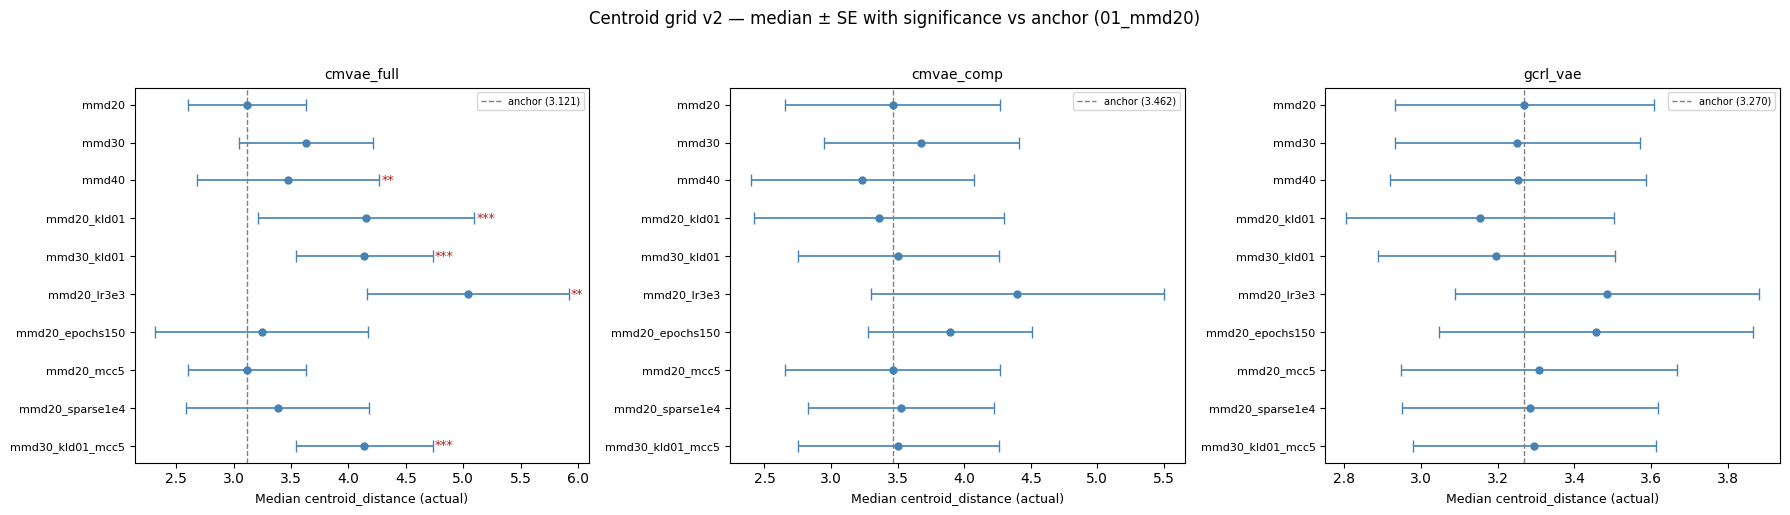

In [18]:
fig, axes = plt.subplots(1, len(SUBMODELS), figsize=(6 * len(SUBMODELS), 5), sharey=False)

short_names = {s: s.split("_", 1)[1] for s in SETTINGS}

# Forest plot uses only actual predictions
summary_actual = summary[summary["method"] == "actual"]

for ax, sub in zip(axes, SUBMODELS):
    sub_sum = summary_actual[summary_actual["model"] == sub].set_index("setting").reindex(SETTINGS)
    anchor_med = sub_sum.loc[ANCHOR_SETTING, "median"]

    y_pos = np.arange(len(SETTINGS))
    ax.errorbar(
        sub_sum["median"], y_pos,
        xerr=sub_sum["se"],
        fmt="o", color="steelblue", ecolor="steelblue",
        capsize=4, linewidth=1.2, markersize=5,
    )
    ax.axvline(anchor_med, color="gray", linestyle="--", linewidth=1, label=f"anchor ({anchor_med:.3f})")

    # Add significance markers from vs_anchor
    sub_anch = vs_anchor[vs_anchor["model"] == sub].set_index("setting")
    for i, name in enumerate(SETTINGS):
        if name == ANCHOR_SETTING:
            continue
        if name in sub_anch.index:
            sig = sub_anch.loc[name, "sig"]
            if sig and sig != "ns":
                ax.text(
                    sub_sum.loc[name, "median"] + sub_sum.loc[name, "se"] + 0.02,
                    i, sig, va="center", fontsize=9, color="firebrick"
                )

    ax.set_yticks(y_pos)
    ax.set_yticklabels([short_names[s] for s in SETTINGS], fontsize=8)
    ax.set_xlabel(f"Median {METRIC} (actual)", fontsize=9)
    ax.set_title(sub, fontsize=10)
    ax.legend(fontsize=7)
    ax.invert_yaxis()

plt.suptitle("Centroid grid v2 — median ± SE with significance vs anchor (01_mmd20)", y=1.02)
plt.tight_layout()
plt.show()

## 6. Heatmap: gCRL-VAE p-values and deltas vs all four references

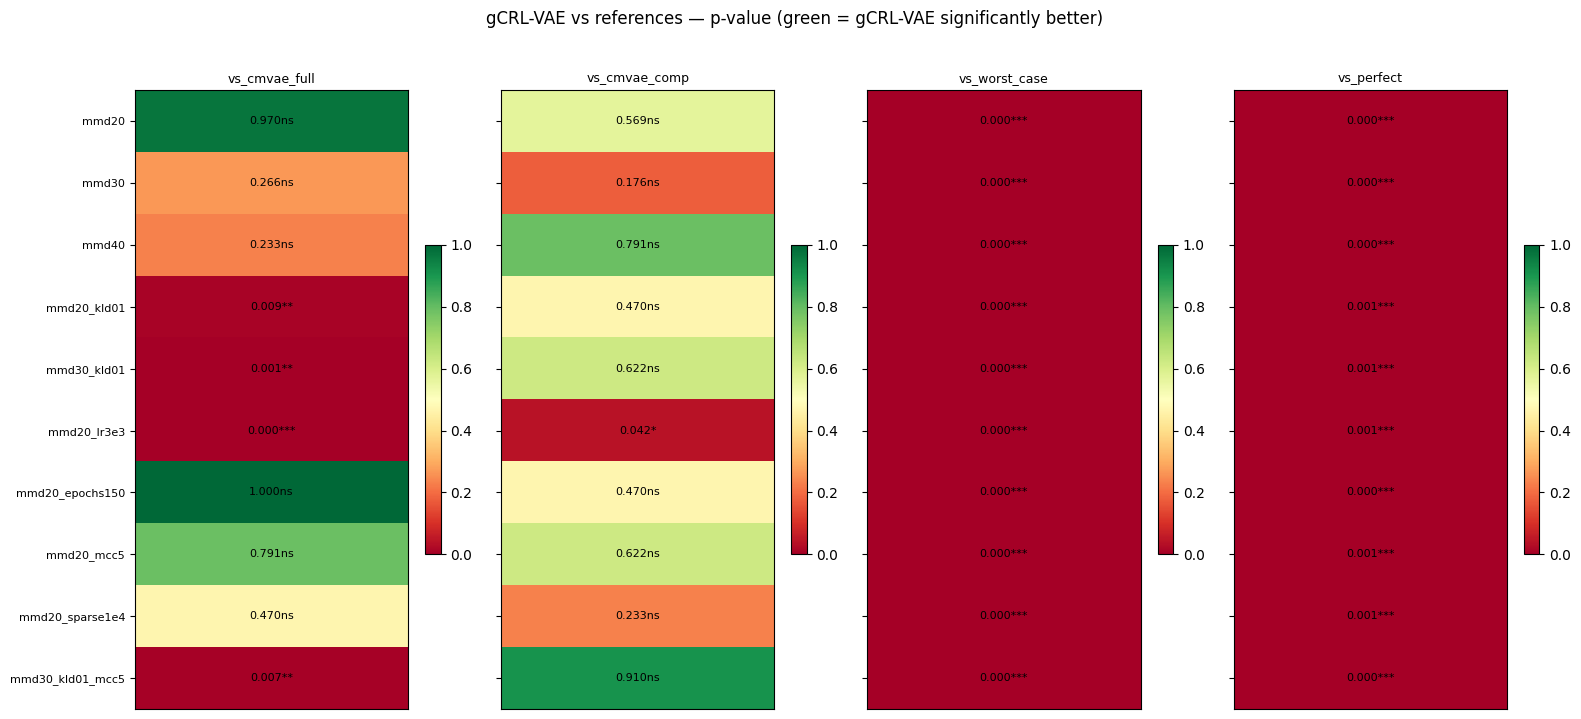

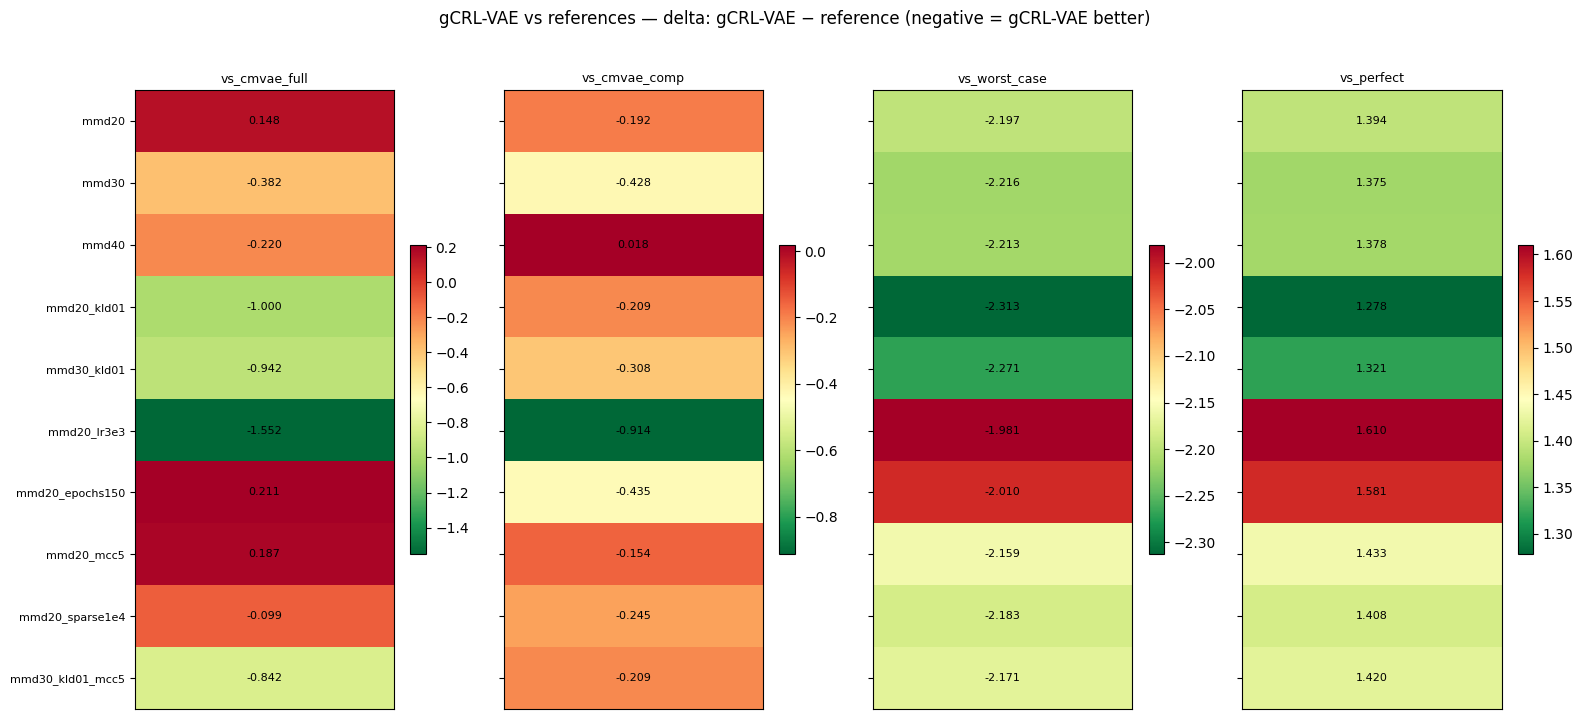

In [19]:
short_names  = {s: s.split("_", 1)[1] for s in SETTINGS}
ref_labels   = [r for r, _, _ in REFERENCES]

for metric_col, cmap_name, title_suffix in [
    ("p_value", "RdYlGn",   "p-value (green = gCRL-VAE significantly better)"),
    ("delta",   "RdYlGn_r", "delta: gCRL-VAE − reference (negative = gCRL-VAE better)"),
]:
    fig, axes = plt.subplots(1, len(ref_labels), figsize=(4 * len(ref_labels), 7), sharey=True)
    for ax, ref_label in zip(axes, ref_labels):
        sub = gcrl_vs[gcrl_vs["reference"] == ref_label].set_index("setting").reindex(SETTINGS)
        vals = sub[metric_col].values.reshape(-1, 1).astype(float)
        im = ax.imshow(vals, aspect="auto",
                       cmap=cmap_name,
                       vmin=0 if metric_col == "p_value" else None,
                       vmax=1 if metric_col == "p_value" else None)
        plt.colorbar(im, ax=ax, shrink=0.5)
        ax.set_xticks([])
        ax.set_yticks(range(len(SETTINGS)))
        ax.set_yticklabels([short_names[s] for s in SETTINGS], fontsize=8)
        ax.set_title(ref_label, fontsize=9)
        for i, name in enumerate(SETTINGS):
            v   = sub.loc[name, metric_col]
            sig = sub.loc[name, "sig"] if metric_col == "p_value" else ""
            if not np.isnan(v):
                ax.text(0, i, f"{v:.3f}{sig}", ha="center", va="center", fontsize=8)
    plt.suptitle(f"gCRL-VAE vs references — {title_suffix}", y=1.02)
    plt.tight_layout()
    plt.show()